In [6]:
import os

os.listdir()

['.config', 'cleaned_data.csv', 'sample_data']

In [7]:
# Reload dataset
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

# Targets
y_reg = df["adr"]
y_clf = df["is_canceled"]

# Features
X = df.drop(columns=[
    "adr",
    "is_canceled",
    "reservation_status",
    "reservation_status_date"
])

# Encode categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Final Shape:", X.shape)

Final Shape: (87370, 245)


In [8]:
print(X.shape)

(87370, 245)


In [9]:
from sklearn.model_selection import train_test_split

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

print("Regression Train:", X_train_reg.shape)
print("Regression Test :", X_test_reg.shape)

print()

print("Classification Train:", X_train_clf.shape)
print("Classification Test :", X_test_clf.shape)

Regression Train: (69896, 245)
Regression Test : (17474, 245)

Classification Train: (69896, 245)
Classification Test : (17474, 245)


In [10]:
from sklearn.preprocessing import StandardScaler

# Regression scaler
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Classification scaler
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Scaling completed successfully.")


Scaling completed successfully.


In [11]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_reg_scaled, y_train_reg)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [12]:
y_pred_reg = linear_model.predict(X_test_reg_scaled)

print(y_pred_reg[:10])

[ 99.5529613  107.00870644 139.3709175   98.61305988 149.36124214
 155.21096696  78.306989    41.34251527 169.4510068  242.00308479]


In [13]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 985.5543265511167
R² Score: 0.6476109946768231


In [14]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print(coefficients.head(10))

                          Feature  Coefficient  Absolute Coefficient
18      arrival_date_month_August    23.840662             23.840662
2        arrival_date_week_number   -17.727700             17.727700
22        arrival_date_month_July    16.587185             16.587185
28   arrival_date_month_September    15.364755             15.364755
17             hotel_Resort Hotel   -11.879272             11.879272
27     arrival_date_month_October    11.725881             11.725881
21     arrival_date_month_January   -10.870266             10.870266
1               arrival_date_year    10.833708             10.833708
214      market_segment_Online TA    10.804194             10.804194
20    arrival_date_month_February    -9.865371              9.865371


In [15]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_reg_scaled, y_train_reg)

y_pred_ridge = ridge_model.predict(X_test_reg_scaled)

ridge_mse = mean_squared_error(y_test_reg, y_pred_ridge)
ridge_r2 = r2_score(y_test_reg, y_pred_ridge)

print("Ridge Regression Results")
print("------------------------")
print("MSE :", ridge_mse)
print("R²  :", ridge_r2)

Ridge Regression Results
------------------------
MSE : 985.5896760496956
R²  : 0.647598355318132


In [16]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R2 Score": [r2, ridge_r2]
})

print(comparison)

               Model         MSE  R2 Score
0  Linear Regression  985.554327  0.647611
1   Ridge Regression  985.589676  0.647598


In [17]:
print(y_train_clf.value_counts())

print()

print(y_train_clf.value_counts(normalize=True) * 100)

is_canceled
0    50614
1    19282
Name: count, dtype: int64

is_canceled
0    72.4133
1    27.5867
Name: proportion, dtype: float64


In [18]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
# class_weight='balanced' is used because the dataset is imbalanced
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_clf_scaled, y_train_clf)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [19]:
# Predict the class labels
y_pred_clf = logistic_model.predict(X_test_clf_scaled)

# Predict the probabilities
y_prob_clf = logistic_model.predict_proba(X_test_clf_scaled)[:, 1]

print("Predictions completed successfully.")

Predictions completed successfully.


In [20]:
# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)

print("Confusion Matrix")
print(cm)

print()

# Classification Report
print("Classification Report")
print(classification_report(y_test_clf, y_pred_clf))

print()

# Accuracy
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print("Accuracy:", accuracy)

Confusion Matrix
[[9382 3350]
 [1057 3685]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.74      0.81     12732
           1       0.52      0.78      0.63      4742

    accuracy                           0.75     17474
   macro avg       0.71      0.76      0.72     17474
weighted avg       0.80      0.75      0.76     17474


Accuracy: 0.7477967265651826


AUC Score: 0.8390120361452058


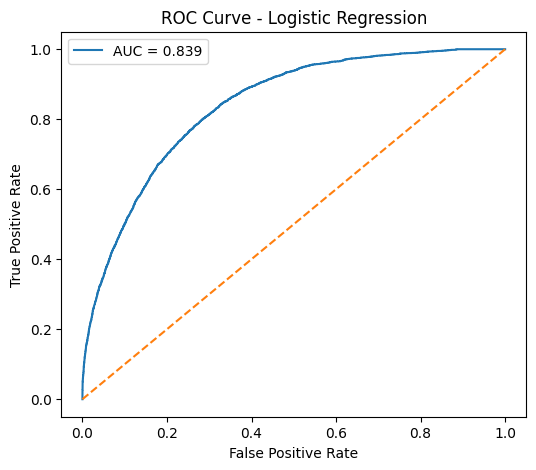

In [21]:
# Import required libraries
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf)

# Calculate AUC Score
auc_score = roc_auc_score(y_test_clf, y_prob_clf)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [22]:
# Import required metrics
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Create different thresholds
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

# Check model performance at each threshold
for threshold in thresholds:

    # Convert probabilities into class labels
    predictions = (y_prob_clf >= threshold).astype(int)

    # Calculate evaluation metrics
    precision = precision_score(y_test_clf, predictions)
    recall = recall_score(y_test_clf, predictions)
    f1 = f1_score(y_test_clf, predictions)

    # Store the results
    results.append([threshold, precision, recall, f1])

# Create a DataFrame
threshold_table = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

print(threshold_table)

   Threshold  Precision    Recall  F1 Score
0        0.3   0.419808  0.932307  0.578930
1        0.4   0.470313  0.870308  0.610638
2        0.5   0.523810  0.777098  0.625796
3        0.6   0.585297  0.659848  0.620341
4        0.7   0.644949  0.515605  0.573069


In [24]:
# Train Logistic Regression with stronger regularization (C = 0.01)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Create Logistic Regression model
log_reg_strong = LogisticRegression(
    C=0.01,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg_strong.fit(X_train_clf_scaled, y_train_clf)

# Predictions
y_pred_strong = log_reg_strong.predict(X_test_clf_scaled)
y_prob_strong = log_reg_strong.predict_proba(X_test_clf_scaled)[:, 1]

# Evaluation
precision_strong = precision_score(y_test_clf, y_pred_strong)
recall_strong = recall_score(y_test_clf, y_pred_strong)
auc_strong = roc_auc_score(y_test_clf, y_prob_strong)

print("Precision :", precision_strong)
print("Recall    :", recall_strong)
print("AUC Score :", auc_strong)

Precision : 0.522532800912721
Recall    : 0.7726697595951075
AUC Score : 0.8384745136177231


In [25]:
comparison = pd.DataFrame({
    "Model": ["C = 1.0", "C = 0.01"],
    "Precision": [
        precision_score(y_test_clf, y_pred_clf),
        precision_strong
    ],
    "Recall": [
        recall_score(y_test_clf, y_pred_clf),
        recall_strong
    ],
    "AUC": [
        auc_score,
        auc_strong
    ]
})

print(comparison)

      Model  Precision    Recall       AUC
0   C = 1.0   0.523810  0.777098  0.839012
1  C = 0.01   0.522533  0.772670  0.838475


In [26]:
# Bootstrap Confidence Interval for AUC Difference

import numpy as np
from sklearn.metrics import roc_auc_score

# Store AUC differences
auc_differences = []

# Repeat 500 times
for i in range(500):

    # Randomly sample test indices with replacement
    indices = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    # Bootstrap samples
    y_boot = y_test_clf.iloc[indices]

    prob_c1 = y_prob_clf[indices]
    prob_c001 = y_prob_strong[indices]

    # Calculate AUC
    auc_c1 = roc_auc_score(y_boot, prob_c1)
    auc_c001 = roc_auc_score(y_boot, prob_c001)

    # Store difference
    auc_differences.append(auc_c1 - auc_c001)

# Mean Difference
mean_difference = np.mean(auc_differences)

# 95% Confidence Interval
lower = np.percentile(auc_differences, 2.5)
upper = np.percentile(auc_differences, 97.5)

print("Mean AUC Difference :", mean_difference)
print("95% Confidence Interval:")
print("Lower Bound :", lower)
print("Upper Bound :", upper)

Mean AUC Difference : 0.0005421371590131103
95% Confidence Interval:
Lower Bound : 0.0002388176948510984
Upper Bound : 0.0008534050348481064
